In [14]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
import matplotlib.pyplot as plt
from collections import deque
from graphviz import Digraph
import heapq

In [4]:
service = Service(executable_path="chromedriver-win64/chromedriver.exe")
driver = webdriver.Chrome(service=service)
url = "https://pages.cs.wisc.edu/~yw/CS320TH1.html"
driver.get(url)
print("DONE")

DONE


In [5]:
def get_links():
    links = driver.find_elements("tag name", "a")
    pages = list(filter(lambda x : x.text == "Link", links))
    hrefs = list(map(lambda x : x.get_attribute("href"), pages))
    return hrefs

get_links()

['https://pages.cs.wisc.edu/~yw/CS320TH2.html',
 'https://pages.cs.wisc.edu/~yw/CS320TH3.html',
 'https://pages.cs.wisc.edu/~yw/CS320TH4.html']

In [6]:
def goal_check():
    image = driver.find_elements("tag name", "img")
    if len(image) == 2:
        image[0].screenshot("image.png")
        print(image[0].get_attribute("src"))
        plt.imshow(plt.imread("image.png"))
        return True
    return False

goal_check()

False

https://pages.cs.wisc.edu/~yw/CS320/amongus.png


'https://pages.cs.wisc.edu/~yw/CS320TH23.html'

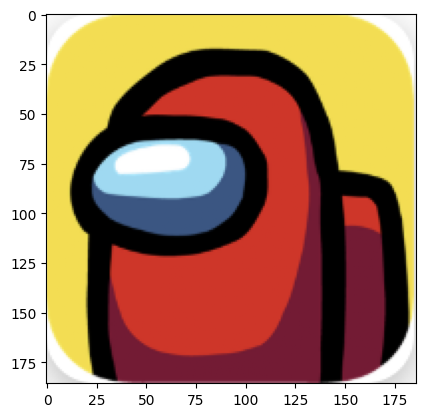

In [7]:
def crawl(url):
    visited = set()
    queue = deque([url])
    found = False
    count = 0 # avoid infinite loop
    while count < 100:
        count = count + 1
        current = queue.popleft()
        visited.add(current)
        driver.get(current)
        found = goal_check()
        if found:
            return current
        links = get_links()
        for link in links:
            if not link in visited and not link in queue:
                queue.append(link)
        if len(queue) == 0:
            break

url = "https://pages.cs.wisc.edu/~yw/CS320TH1.html"
crawl(url)

In [8]:
driver.quit()

In [10]:
service = Service(executable_path="chromedriver-win64/chromedriver.exe")
driver = webdriver.Chrome(service=service)
url = "https://pages.cs.wisc.edu/~yw/CS320F23TH1.html"
driver.get(url)
print("DONE")

DONE


In [11]:
def page_name(link):
    start = link.index("TH") + 2
    end = link.index(".html")
    if start >= 0 and end >= 0:
        return link[start:end]
    return ""

page_name(url)

'1'

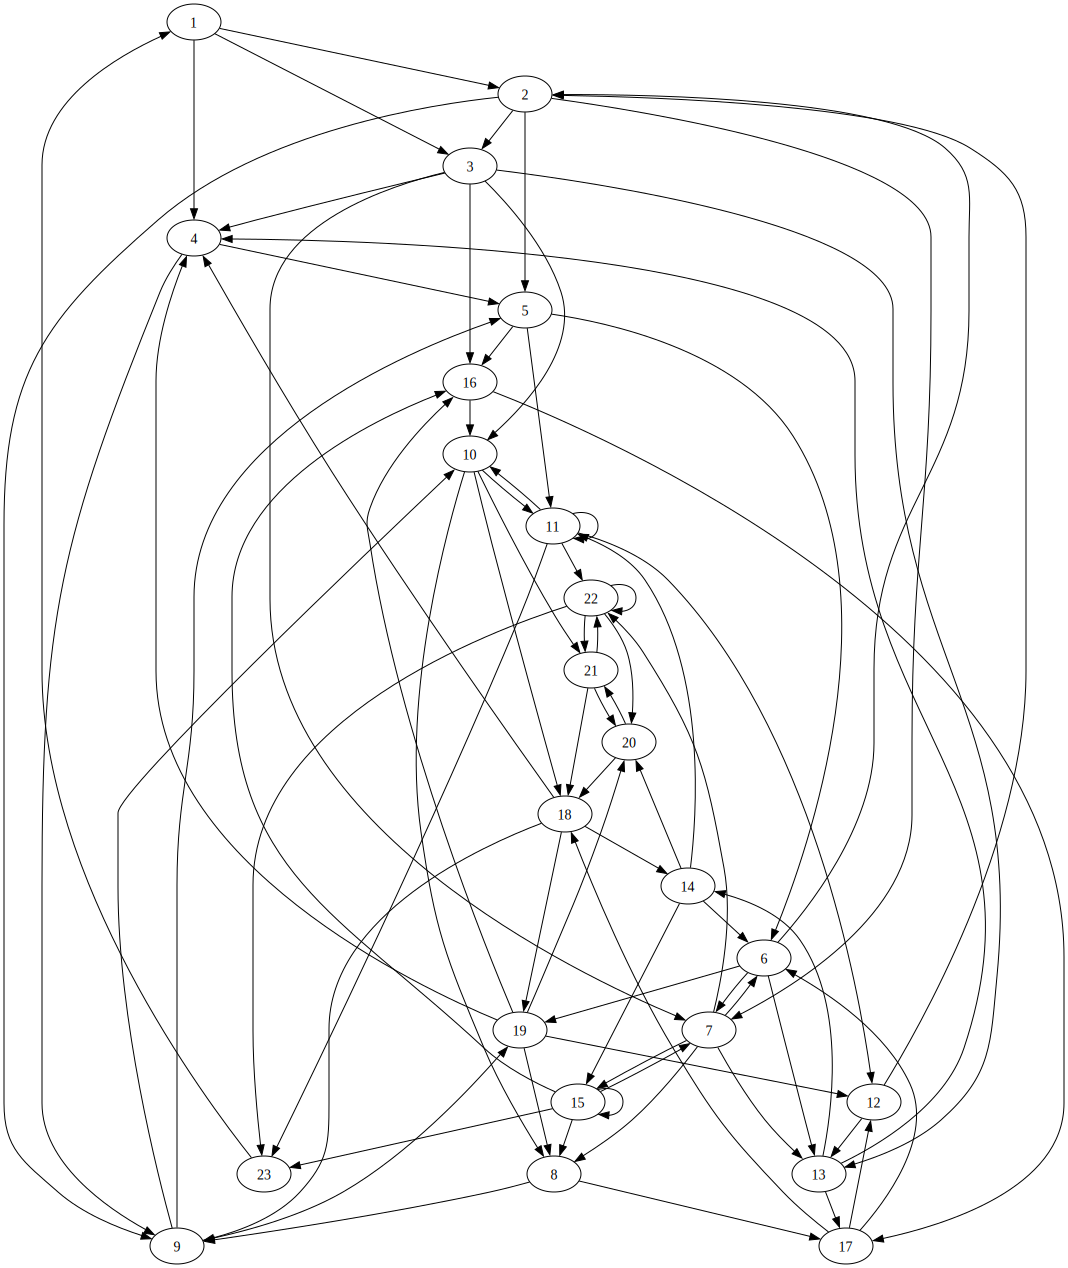

In [12]:
def crawl(url):
    visited = set()
    queue = deque([url])
    graph = Digraph()
    count = 0 # avoid infinite loop
    while count < 30:
        count = count + 1
        current = queue.popleft()
        visited.add(current)
        driver.get(current)
        graph.node(page_name(current))
        links = get_links()
        for link in links:
            graph.edge(page_name(current), page_name(link))
            if not link in visited and not link in queue:
                queue.append(link)
        if len(queue) == 0:
            break
    return graph

url = "https://pages.cs.wisc.edu/~yw/CS320TH1.html"
crawl(url)

In [17]:
driver.quit()

In [18]:
service = Service(executable_path="chromedriver-win64/chromedriver.exe")
driver = webdriver.Chrome(service=service)
url = "https://pages.cs.wisc.edu/~yw/CS320THH1.html"
driver.get(url)
print("DONE")

DONE


In [19]:
def get_links():
    links = driver.find_elements("tag name", "a")
    pages = list(filter(lambda x : x.text == "Link", links))
    hrefs = []
    for i in range(len(pages)):
        span = driver.find_element("id", "h" + str(i + 1))
        h = float(span.text)
        hrefs.append((h, pages[i].get_attribute("href")))
    return hrefs

get_links()

[(3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH2.html'),
 (3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH3.html'),
 (3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH4.html')]

In [20]:
def goal_check():
    image = driver.find_elements("tag name", "img")
    if len(image) == 2:
        image[0].screenshot("image_gbs.png")
        print(image[0].get_attribute("src"))
        plt.imshow(plt.imread("image_gbs.png"))
        return True
    return False

goal_check()

False

(0, 'https://pages.cs.wisc.edu/~yw/CS320THH1.html')
(3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH2.html')
(2.0, 'https://pages.cs.wisc.edu/~yw/CS320THH5.html')
(1.0, 'https://pages.cs.wisc.edu/~yw/CS320THH11.html')
(0.0, 'https://pages.cs.wisc.edu/~yw/CS320THH23.html')
https://pages.cs.wisc.edu/~yw/CS320/amongus.png


'https://pages.cs.wisc.edu/~yw/CS320THH23.html'

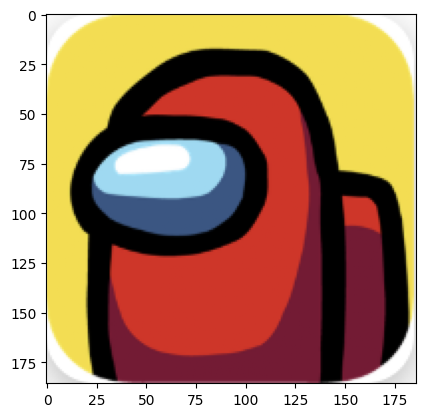

In [21]:
def crawl(url):
    visited = set()
    queue = [(0, url)]
    found = False
    count = 0 # avoid infinite loop
    while count < 100:
        count = count + 1
        current = heapq.heappop(queue)
        if not current[1] in visited:
            visited.add(current[1])
            driver.get(current[1])
            print(current)
            found = goal_check()
            if found:
                return current[1]
            links = get_links()
            for link in links:
                if not link[1] in visited:
                    heapq.heappush(queue, link)
        if len(queue) == 0:
            break

url = "https://pages.cs.wisc.edu/~yw/CS320THH1.html"
crawl(url)

In [22]:
driver.quit()

In [25]:
service = Service(executable_path="chromedriver-win64/chromedriver.exe")
driver = webdriver.Chrome(service=service)
url = "https://pages.cs.wisc.edu/~yw/CS320THH1.html"
driver.get(url)
print("DONE")

DONE


In [26]:
def get_links(g):
    links = driver.find_elements("tag name", "a")
    pages = list(filter(lambda x : x.text == "Link", links))
    hrefs = []
    for i in range(len(pages)):
        span = driver.find_element("id", "h" + str(i + 1))
        h = float(span.text)
        hrefs.append((g + h, g, h, pages[i].get_attribute("href")))
    return hrefs

get_links(0)

[(3.0, 0, 3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH2.html'),
 (3.0, 0, 3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH3.html'),
 (3.0, 0, 3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH4.html')]

In [27]:
def goal_check():
    image = driver.find_elements("tag name", "img")
    if len(image) == 2:
        image[0].screenshot("image_a.png")
        print(image[0].get_attribute("src"))
        plt.imshow(plt.imread("image_a.png"))
        return True
    return False

goal_check()

False

(0, 0, 0, 'https://pages.cs.wisc.edu/~yw/CS320THH1.html')
(4.0, 1, 3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH2.html')
(4.0, 1, 3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH3.html')
(4.0, 1, 3.0, 'https://pages.cs.wisc.edu/~yw/CS320THH4.html')
(4.0, 2, 2.0, 'https://pages.cs.wisc.edu/~yw/CS320THH10.html')
(4.0, 2, 2.0, 'https://pages.cs.wisc.edu/~yw/CS320THH5.html')
(4.0, 2, 2.0, 'https://pages.cs.wisc.edu/~yw/CS320THH7.html')
(4.0, 3, 1.0, 'https://pages.cs.wisc.edu/~yw/CS320THH11.html')
(4.0, 3, 1.0, 'https://pages.cs.wisc.edu/~yw/CS320THH15.html')
(4.0, 3, 1.0, 'https://pages.cs.wisc.edu/~yw/CS320THH22.html')
(4.0, 4, 0.0, 'https://pages.cs.wisc.edu/~yw/CS320THH23.html')
https://pages.cs.wisc.edu/~yw/CS320/amongus.png


'https://pages.cs.wisc.edu/~yw/CS320THH23.html'

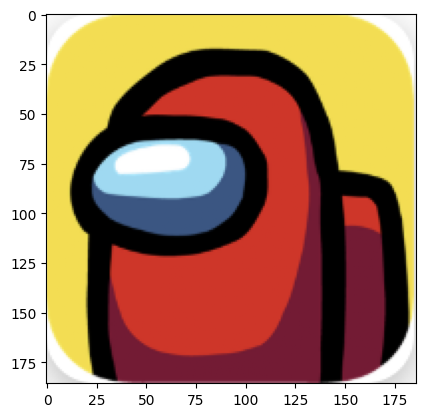

In [28]:
def crawl(url):
    visited = set()
    queue = [(0, 0, 0, url)]
    found = False
    count = 0 # avoid infinite loop
    while count < 100:
        count = count + 1
        current = heapq.heappop(queue)
        if not current[3] in visited:
            visited.add(current[3])
            driver.get(current[3])
            print(current)
            found = goal_check()
            if found:
                return current[3]
            links = get_links(current[1] + 1)
            for link in links:
                if not link[3] in visited:
                    heapq.heappush(queue, link)
        if len(queue) == 0:
            break

url = "https://pages.cs.wisc.edu/~yw/CS320THH1.html"
crawl(url)

In [29]:
driver.quit()